In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import math
from sklearn.metrics import silhouette_score

## Load Data

In [2]:
df = pd.read_csv('data/Mall_Customers.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [7]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [8]:
#irrelevant column
df.drop(columns=['CustomerID'], inplace=True)

## Visualization

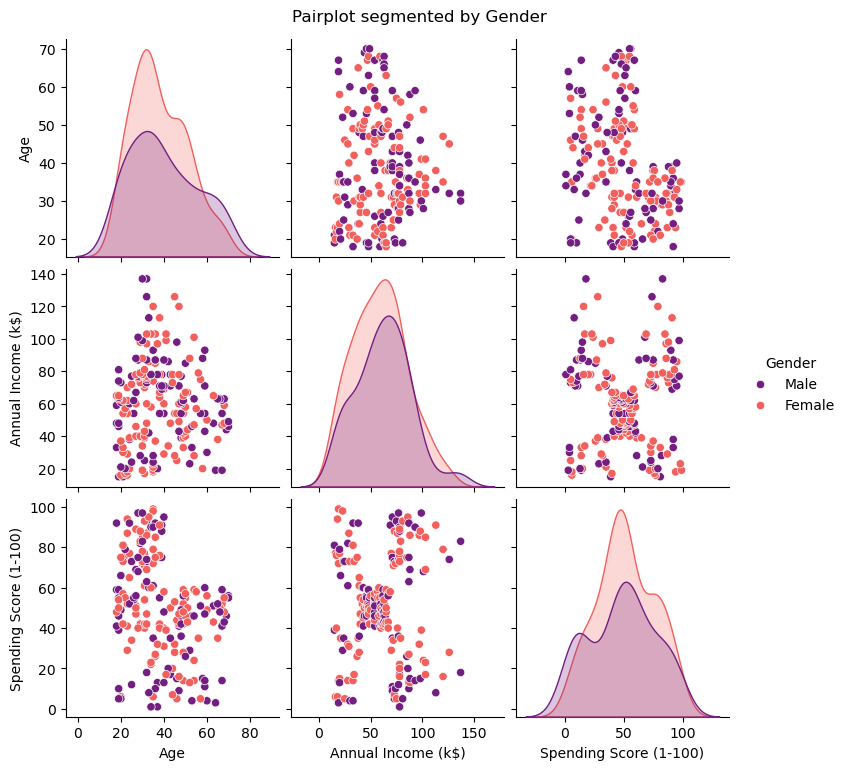

In [9]:
#parplot including gender
sns.pairplot(df, hue='Gender', palette='magma')
plt.suptitle("Pairplot segmented by Gender", y=1.02)
plt.show()

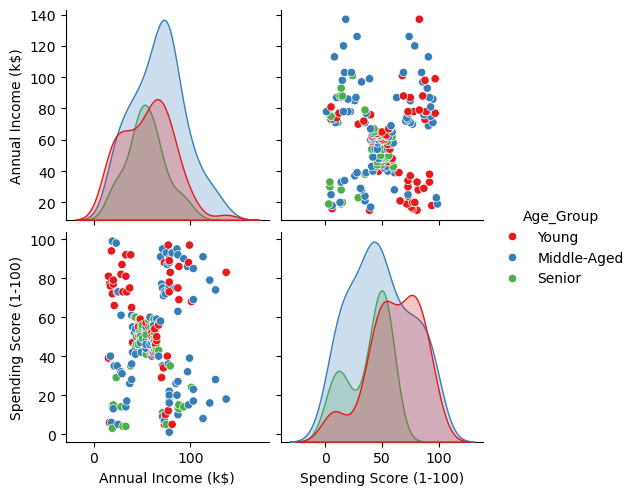

In [10]:
#make a new column for age group
df_temp = df.copy()
df_temp['Age_Group'] = pd.cut(df_temp['Age'], 
                         bins=[0, 30, 50, 100], 
                         labels=['Young', 'Middle-Aged', 'Senior'])

sns.pairplot(df_temp.drop('Age', axis=1), hue='Age_Group', palette='Set1')
plt.show()

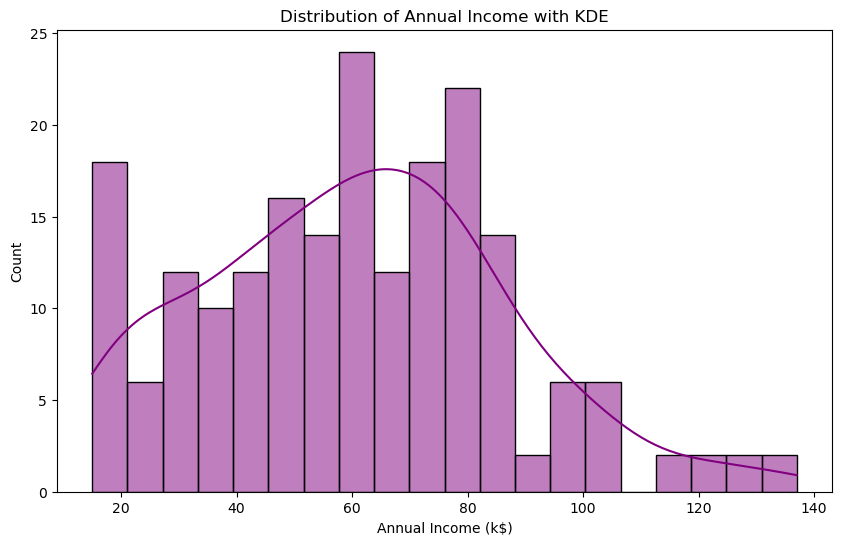

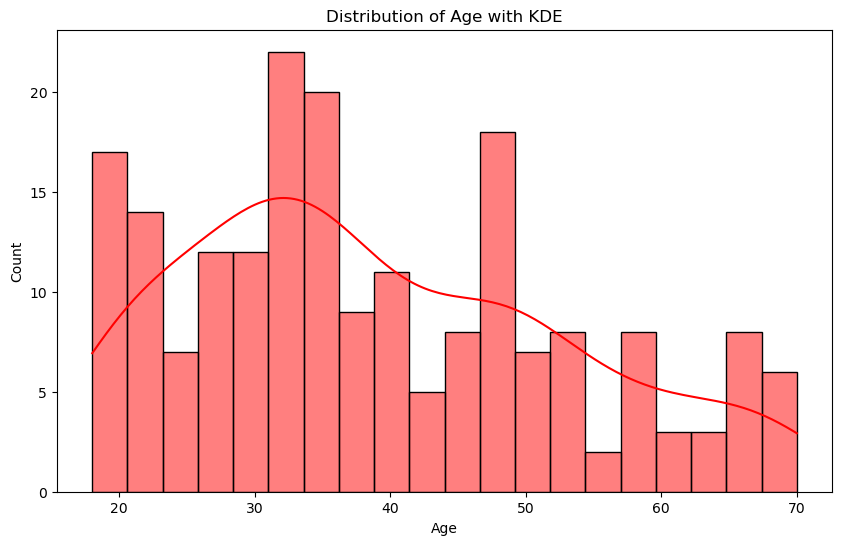

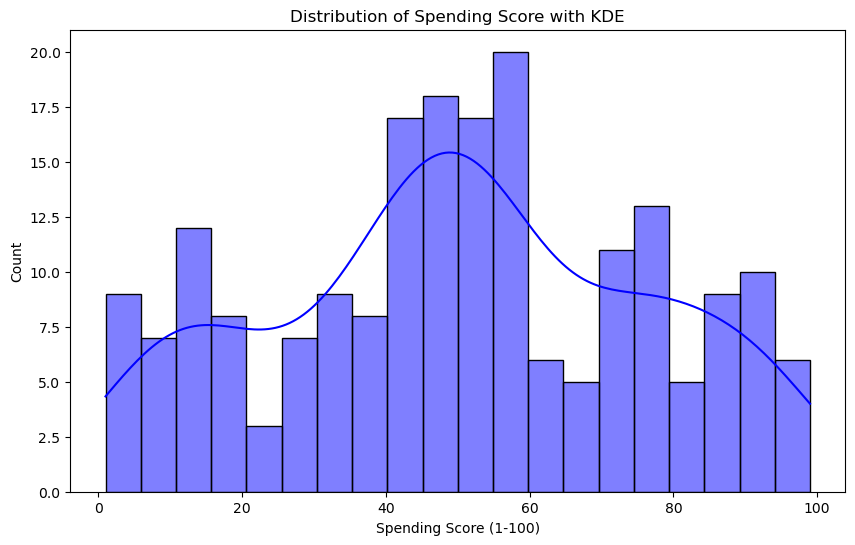

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Annual Income (k$)'], kde=True, color='purple', bins=20)
plt.title('Distribution of Annual Income with KDE')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='red', bins=20)
plt.title('Distribution of Age with KDE')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Spending Score (1-100)'], kde=True, color='blue', bins=20)
plt.title('Distribution of Spending Score with KDE')
plt.show()

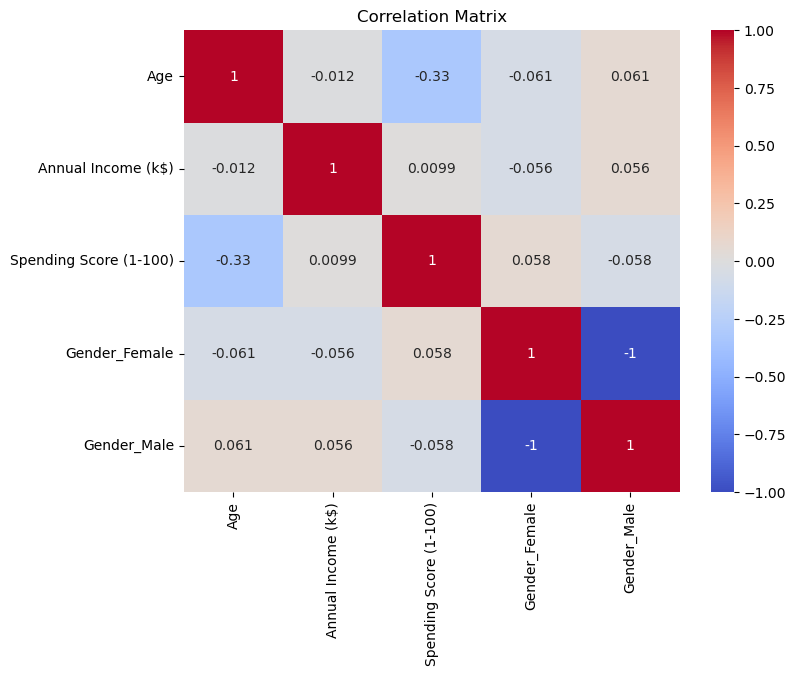

In [12]:
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=False)

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

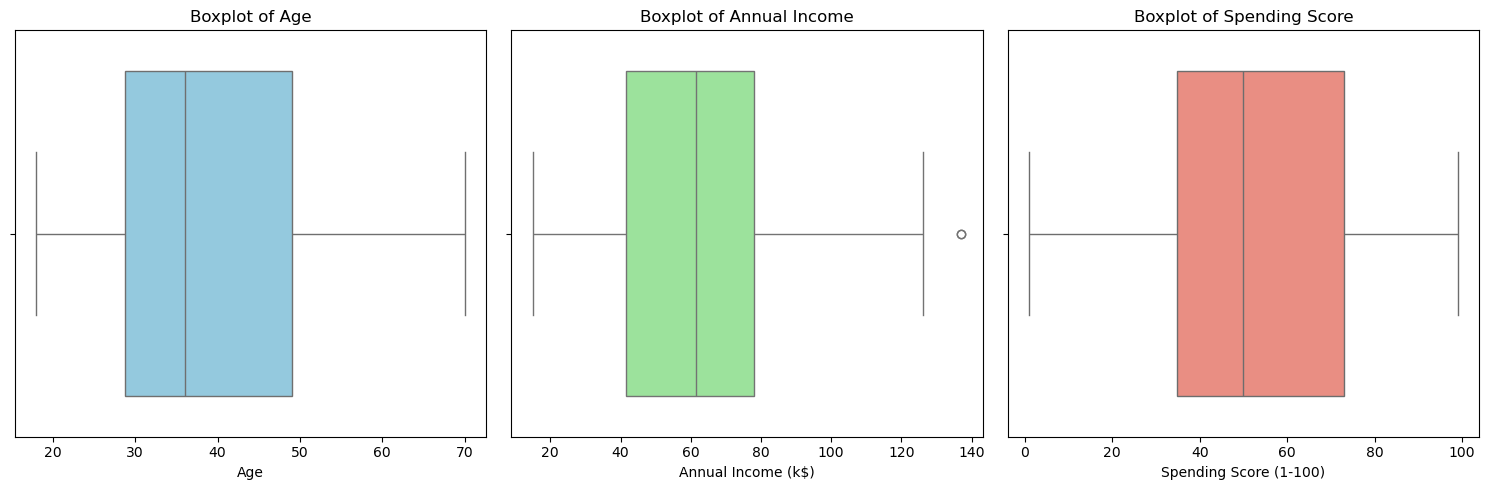

In [13]:
#outliers
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Boxplot of Age')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['Annual Income (k$)'], color='lightgreen')
plt.title('Boxplot of Annual Income')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['Spending Score (1-100)'], color='salmon')
plt.title('Boxplot of Spending Score')

plt.tight_layout()
plt.show()

In [14]:
cols_to_check = df.select_dtypes(include=['float64','int64']).columns

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col} : {outliers}")

Age : 0
Annual Income (k$) : 2
Spending Score (1-100) : 0
